In [18]:
!wget https://www.ssa.gov/oact/babynames/names.zip

--2026-03-18 16:12:58--  https://www.ssa.gov/oact/babynames/names.zip
Resolving www.ssa.gov (www.ssa.gov)... 23.46.228.170, 23.46.228.173, 2600:1409:9800:1d::17d8:9118, ...
Connecting to www.ssa.gov (www.ssa.gov)|23.46.228.170|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7726516 (7.4M) [application/zip]
Saving to: ‘names.zip’

names.zip           100%[===================>]   7.37M  35.0MB/s    in 0.2s    

2026-03-18 16:12:58 (35.0 MB/s) - ‘names.zip’ saved [7726516/7726516]



In [19]:
zip_data  = zipfile.ZipFile("names.zip")

In [21]:
zip_data.namelist()[:5]

['yob1880.txt', 'yob1881.txt', 'yob1882.txt', 'yob1883.txt', 'yob1884.txt']

In [26]:
data_list = []

for file in zip_data.namelist():
    if file.startswith("yob"):
        df = pd.read_csv(zip_data.open(file), names=['Name', 'Gender', 'Count'])
        df['Year'] = int(file[3:7])
        data_list.append(df)

data = pd.concat(data_list, ignore_index=True)

data.head()

,Name,Gender,Count,Year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


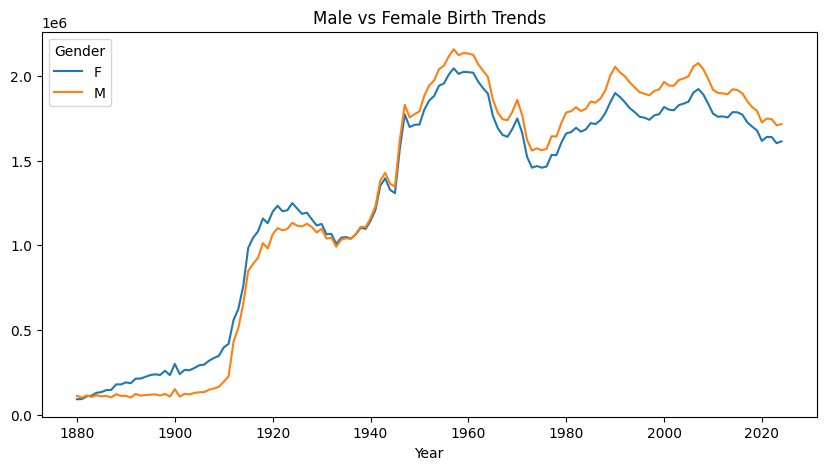

In [27]:
gender_year = data.groupby(['Year','Gender'])['Count'].sum().unstack()

gender_year.plot(figsize=(10,5))
plt.title("Male vs Female Birth Trends")
plt.show()

In [31]:
data.groupby('Name')['Count'].sum().sort_values(ascending=False).head(15)

,Count
Name,
James,5262396
John,5196210
Robert,4866007
Michael,4440391
William,4205026
Mary,4154332
David,3682683
Joseph,2672746
Richard,2585535


In [39]:
data.sort_values(['Year','Count'],
ascending=[True,False]) \
    .groupby('Year') \
    .head(1)

,Name,Gender,Count,Year
942,John,M,9655,1880
2938,John,M,8768,1881
4962,John,M,9557,1882
7115,John,M,8894,1883
9317,John,M,9388,1884
...,...,...,...,...
2007888,Liam,M,19858,2020
2039608,Liam,M,20407,2021
2071448,Liam,M,20563,2022
2103367,Liam,M,20886,2023


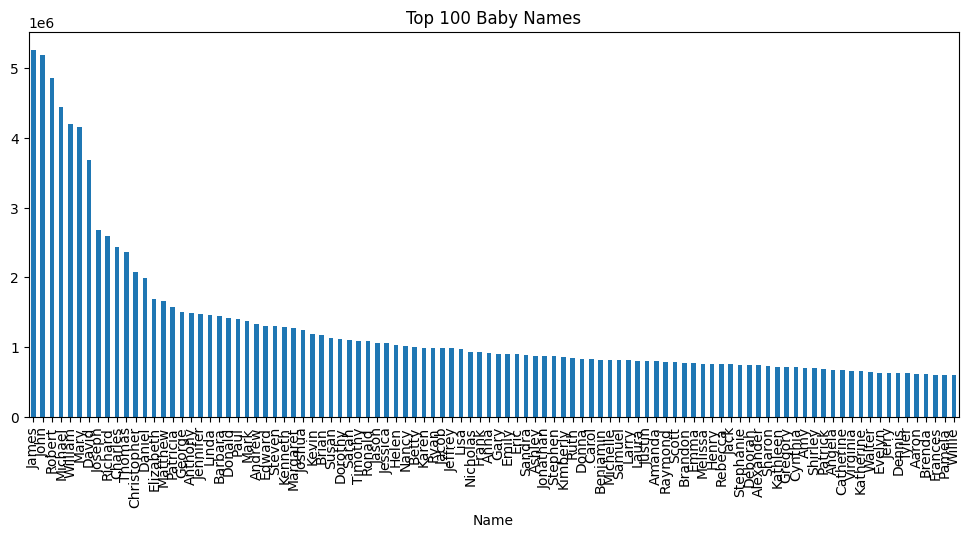

In [46]:
top100 = data.groupby('Name')['Count'].sum().sort_values(ascending =False).head(100)

top100.plot(kind='bar',
figsize=(12,5))
plt.title("Top 100 Baby Names")
plt.show()

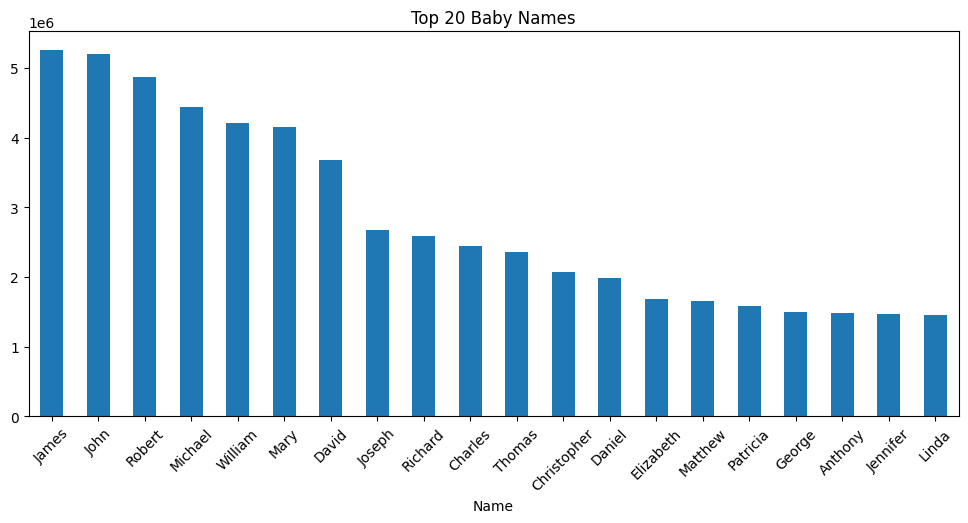

In [47]:
top100.head(20).plot(kind='bar', figsize=(12,5))
plt.title("Top 20 Baby Names")
plt.xticks(rotation=45)
plt.show()